[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/SFM/blob/main/notebooks/EN/chapter9_lecture_notebook.ipynb)

# Statistics of Financial Markets — Chapter 9: ARCH and GARCH models

*Lecture notebook. Daniel Traian Pele, Bucharest University of Economic Studies.*

- Volatility clustering in the S&P 500 since 2000; the 2008 and 2020 episodes.
- Simulated ARCH(1) and GARCH(1,1) paths (SFEtimegarch); the likelihood of ARCH(1) and GARCH(1,1) (SFElikarch1, SFElikgarch).
- Maximum-likelihood estimation step by step and with the `arch` package (SFEgarchest); robust standard errors; Student-t and skewed-t innovations.
- GARCH(1,1)-t in six markets; conditional volatility (SFEvolgarchest); persistence and half-life.
- Asymmetry: GJR-GARCH, EGARCH, the news impact curve (SFENewsImpactCurve); diagnostics; AIC and BIC.
- Multi-step forecasts; out-of-sample comparison with EWMA (QLIKE, Diebold–Mariano); VaR 1%.
- References: Franke, Härdle and Hafner (2019), *Statistics of Financial Markets*, 5th ed., Ch. 13; Tsay (2010), *Analysis of Financial Time Series*, 3rd ed., Ch. 3; Engle (1982); Bollerslev (1986).

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [1]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/SFM/Chapter_9'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


Save your outputs to: /Users/danpele/Documents/Teaching/SFM - Statistica pietelor financiare/2026/notebooks/EN


In [2]:
# the arch package (maximum-likelihood estimation of GARCH models) is not part of Google Colab
!pip install -q arch

In [3]:
import os
import re
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from scipy import optimize
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Chart style

- Transparent background, legend below the plot, course palette.

In [4]:
# Palette (RGB values of latex/preamble.tex)
MainBlue = '#1A3A6E'
IDAred = '#CD0000'
Forest = '#2E7D32'
Amber = '#B5853F'
Orange = '#E67E22'
Purple = '#8E44AD'
Teal = '#17A2B8'
Crimson = '#DC3545'
DarkText = '#1F2A44'          # text, axes and ticks (dark navy, not grey)

PALETTE = [MainBlue, IDAred, Forest, Amber, Purple, Orange, Teal, Crimson]
# fixed colours for the series used in several chapters
COL = {'sp500': MainBlue, 'bet': IDAred, 'bettr': Orange, 'dax': Teal, 'btc': Amber, 'eth': Crimson,
       'eurron': Forest, 'gold': Purple, 'vix': Crimson, 'stoxx50': Forest, 'ndx': Teal}


def apply():
    """Set the course style for matplotlib."""
    rc = plt.rcParams
    rc['figure.facecolor'] = 'none'
    rc['axes.facecolor'] = 'none'
    rc['savefig.facecolor'] = 'none'
    rc['savefig.transparent'] = True
    rc['axes.grid'] = False
    rc['font.family'] = 'sans-serif'
    rc['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
    # font sizes for slides (charts are 9-11 inches wide and shown at 8-14 cm)
    rc['font.size'] = 12
    rc['axes.labelsize'] = 13
    rc['axes.titlesize'] = 13
    rc['xtick.labelsize'] = 11.5
    rc['ytick.labelsize'] = 11.5
    rc['legend.fontsize'] = 11
    rc['axes.spines.top'] = False
    rc['axes.spines.right'] = False
    rc['axes.linewidth'] = 0.6
    rc['lines.linewidth'] = 1.4
    rc['legend.facecolor'] = 'none'
    rc['legend.framealpha'] = 0
    rc['legend.frameon'] = False
    for k in ('text.color', 'axes.labelcolor', 'axes.edgecolor', 'xtick.color', 'ytick.color', 'axes.titlecolor'):
        rc[k] = DarkText
    rc['axes.prop_cycle'] = mpl.cycler(color=PALETTE)


def legend_outside_bottom(ax, ncol=2, y=-0.22, **kw):
    """Place the legend outside the plot, bottom centre (for a figure with several axes, pass the last one
    or use fig.legend with the same arguments)."""
    return ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False, **kw)


def fig_legend_bottom(fig, handles=None, labels=None, ncol=3, y=-0.02):
    """One legend for a whole figure (several panels), below the panels."""
    if handles is None:
        handles, labels = [], []
        for ax in fig.axes:
            for h, l in zip(*ax.get_legend_handles_labels()):
                if l not in labels and not l.startswith('_'):
                    handles.append(h)
                    labels.append(l)
    return fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def _is_grey(c, tol=0.06):
    try:
        r, g, b = to_rgb(c)
    except ValueError:
        return False
    return max(r, g, b) - min(r, g, b) < tol and 0.25 < (r + g + b) / 3 < 0.95


def check_no_grey(fig):
    """House rule: no grey series and no grey text. Raises ValueError listing the offending elements."""
    bad = []
    for ax in fig.axes:
        for ln in ax.get_lines():
            if not ln.get_label().startswith('_') and _is_grey(ln.get_color()):
                bad.append(f'line {ln.get_label()!r}')
        for coll in ax.collections:
            fc = coll.get_facecolor()
            if len(fc) and coll.get_label() and not coll.get_label().startswith('_') and _is_grey(fc[0][:3]):
                bad.append(f'series {coll.get_label()!r}')
        for t in ax.texts + [ax.title, ax.xaxis.label, ax.yaxis.label]:
            if t.get_text() and _is_grey(t.get_color()):
                bad.append(f'text {t.get_text()[:30]!r}')
    if bad:
        raise ValueError('grey elements: ' + ', '.join(bad))


def save_fig(name, out_dir=None, show=True):
    """Save the figure as transparent PDF and PNG (OUT_DIR if defined, else the current folder), then show it."""
    d = out_dir or globals().get('OUT_DIR', '.')
    plt.savefig(os.path.join(d, f'{name}.pdf'), bbox_inches='tight', transparent=True)
    plt.savefig(os.path.join(d, f'{name}.png'), bbox_inches='tight', transparent=True, dpi=180)
    if show:
        plt.show()
    plt.close()


apply()
# the chapter scripts call the style as st.<name> (import sfm_style as st): the same names here
import types
st = types.SimpleNamespace(COL=COL, PALETTE=PALETTE, MainBlue=MainBlue, IDAred=IDAred, Forest=Forest, Amber=Amber,
                           Orange=Orange, Purple=Purple, Teal=Teal, Crimson=Crimson, DarkText=DarkText, apply=apply, legend_outside_bottom=legend_outside_bottom,
                           fig_legend_bottom=fig_legend_bottom, save_fig=save_fig, check_no_grey=check_no_grey)

## Data

- Daily market data from EODHD, saved in `data/market` of the SFM repository (read locally, or from GitHub in Colab); EUR/RON is the official BNR reference rate.
- Returns in %: $r_t = 100(\ln P_t - \ln P_{t-1})$; each series on its own calendar.

In [5]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/SFM/main/data/market/'
# local copy of the course data, if the notebook runs inside the repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'          # last day of the saved data

# name -> (symbol, label, group, field, default start)
SERIES = {
    # equity indices
    'sp500':    ('GSPC.INDX',     'S&P 500',               'Equity', 'close', '2000-01-01'),
    'ndx':      ('NDX.INDX',      'Nasdaq 100',            'Equity', 'close', '2000-01-01'),
    'dax':      ('GDAXI.INDX',    'DAX',                   'Equity', 'close', '2000-01-01'),
    'stoxx50':  ('STOXX50E.INDX', 'Euro Stoxx 50',         'Equity', 'close', '2000-01-01'),
    'nikkei':   ('N225.INDX',     'Nikkei 225',            'Equity', 'close', '2000-01-01'),
    'bet':      ('BET',           'BET',                   'Equity', 'close', '2000-01-01'),
    'bettr':    ('BETTR.INDX',    'BET-TR',                'Equity', 'close', '2014-09-23'),
    'betxt':    ('BETXT.INDX',    'BET-XT',                'Equity', 'close', '2011-08-12'),
    'betfi':    ('BETFI.INDX',    'BET-FI',                'Equity', 'close', '2012-01-25'),
    'wig20':    ('WIG20.INDX',    'WIG20',                 'Equity', 'close', '2000-01-01'),
    'bux':      ('BUX.INDX',      'BUX',                   'Equity', 'close', '2000-01-01'),
    'px':       ('PX.INDX',       'PX',                    'Equity', 'close', '2000-01-01'),
    'vix':      ('VIX.INDX',      'VIX',                   'Volatility', 'close', '2000-01-01'),
    # ETFs (adjusted close)
    'spy':      ('SPY.US',        'SPY',                   'ETF', 'adjusted_close', '2000-01-01'),
    'tlt':      ('TLT.US',        'TLT (US Treasuries 20y+)', 'ETF', 'adjusted_close', '2002-07-30'),
    'gld':      ('GLD.US',        'GLD (gold ETF)',        'ETF', 'adjusted_close', '2004-11-18'),
    'tvbetetf': ('TVBETETF.RO',   'TVBETETF',              'ETF', 'adjusted_close', '2015-06-12'),
    # Bucharest Stock Exchange (adjusted close)
    'tlv':      ('TLV.RO',        'Banca Transilvania',    'Stock', 'adjusted_close', '2000-01-01'),
    'snp':      ('SNP.RO',        'OMV Petrom',            'Stock', 'adjusted_close', '2001-09-04'),
    'brd':      ('BRD.RO',        'BRD',                   'Stock', 'adjusted_close', '2001-01-16'),
    'tgn':      ('TGN.RO',        'Transgaz',              'Stock', 'adjusted_close', '2008-01-25'),
    'sng':      ('SNG.RO',        'Romgaz',                'Stock', 'adjusted_close', '2013-11-12'),
    'snn':      ('SNN.RO',        'Nuclearelectrica',      'Stock', 'adjusted_close', '2013-11-04'),
    'h2o':      ('H2O.RO',        'Hidroelectrica',        'Stock', 'adjusted_close', '2023-07-12'),
    # US stocks (adjusted close)
    'aapl':     ('AAPL.US',       'Apple',                 'Stock', 'adjusted_close', '2000-01-01'),
    'msft':     ('MSFT.US',       'Microsoft',             'Stock', 'adjusted_close', '2000-01-01'),
    'nvda':     ('NVDA.US',       'NVIDIA',                'Stock', 'adjusted_close', '2000-01-01'),
    'jpm':      ('JPM.US',        'JPMorgan Chase',        'Stock', 'adjusted_close', '2000-01-01'),
    # crypto (close, 7 days a week)
    'btc':      ('BTC-USD.CC',    'Bitcoin',               'Crypto', 'close', '2014-09-17'),
    'eth':      ('ETH-USD.CC',    'Ethereum',              'Crypto', 'close', '2015-08-07'),
    'sol':      ('SOL-USD.CC',    'Solana',                'Crypto', 'close', '2020-04-11'),
    'usdt':     ('USDT-USD.CC',   'Tether (USDT)',         'Crypto', 'close', '2015-02-26'),
    # FX and commodities
    'eurron':   ('REF:EUR',       'EUR/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'usdron':   ('REF:USD',       'USD/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'eurron_eodhd': ('EURRON.FOREX', 'EUR/RON (EODHD)',    'FX', 'close', '2005-07-01'),
    'eurusd':   ('EURUSD.FOREX',  'EUR/USD',               'FX', 'close', '2002-05-06'),
    'gold':     ('XAUUSD.FOREX',  'Gold (XAU/USD)',        'Commodity', 'close', '2000-01-01'),
    # government bond yields (close, % p.a.)
    'us10y':    ('US10Y.GBOND',   'US 10Y yield',          'Yield', 'close', '2000-01-01'),
    'de10y':    ('DE10Y.GBOND',   'Germany 10Y yield',     'Yield', 'close', '2007-03-28'),
    'ro10y':    ('RO10Y.GBOND',   'Romania 10Y yield',     'Yield', 'close', '2007-08-17'),
}
LABELS = {k: v[1] for k, v in SERIES.items()}
_CACHE = {}


def read_market(symbol):
    """Daily table of one symbol: local copy of the course data, otherwise the SFM repository on GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname) if MARKET_DIR else ''
    src = path if path and os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def read_reference_rate(currency='EUR', start='2005-07-01', end=END):
    """Official BNR reference rate (RON per unit of currency), from the public yearly XML archives."""
    key = (currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    rows = []
    for y in range(max(int(start[:4]), 2005), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}"(?: multiplier="\d+")?>([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    s = pd.DataFrame(rows, columns=['date', 'close']).drop_duplicates('date').set_index('date')['close']
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.sort_index().loc[start:end]
    return _CACHE[key]


def load_close(name, start=None, end=END, field=None):
    """Daily closing price of a named series, cleaned with the course conventions."""
    symbol, label, group, field0, start0 = SERIES[name]
    start, field = start or start0, field or field0
    if symbol.startswith('REF:'):
        return read_reference_rate(symbol.split(':')[1], start=start, end=end).rename(name)
    t = read_market(symbol)
    s = (t[field] if field in t.columns else t['close']).loc[start:end]
    s = pd.to_numeric(s, errors='coerce').dropna()
    if group != 'Yield':
        s = s[s > 0]
    if group != 'Crypto':
        s = s[s.index.dayofweek < 5]          # no weekend quotes
        s = s[s.diff() != 0]                  # no holidays filled with the previous price
    s.index.name = 'date'
    return s.rename(name)


def load_ohlc(name, start=None, end=END):
    """Open, high, low, close (and volume) of a series with OHLC data (range-based volatility estimators)."""
    symbol, _, group, _, start0 = SERIES[name]
    t = read_market(symbol).loc[start or start0:end]
    cols = [c for c in ('open', 'high', 'low', 'close', 'volume') if c in t.columns]
    t = t[cols].dropna()
    if group != 'Crypto':
        t = t[t.index.dayofweek < 5]
    return t[(t[['open', 'high', 'low', 'close']] > 0).all(axis=1)] if 'open' in cols else t


def log_returns(name, start=None, end=END, pct=True):
    """Daily log returns r_t = ln P_t - ln P_{t-1} (in % by default), on the series' own calendar."""
    r = np.log(load_close(name, start, end)).diff().dropna()
    return (100 * r if pct else r).rename(name)


def simple_returns(name, start=None, end=END, pct=True):
    """Daily simple returns R_t = P_t / P_{t-1} - 1 (in % by default)."""
    r = load_close(name, start, end).pct_change().dropna()
    return (100 * r if pct else r).rename(name)


def load_panel(names, start=None, end=END, kind='close'):
    """Several series aligned on date: kind = 'close' or 'returns' (NaN where a market does not trade)."""
    f = load_close if kind == 'close' else log_returns
    return pd.concat([f(n, start, end) for n in names], axis=1)


def periods_per_year(r):
    """Average number of observations per calendar year (the actual frequency of the series)."""
    years = (r.index[-1] - r.index[0]).days / 365.25
    return len(r) / years

## Definitions used in the whole notebook

- Daily log returns $r_t = 100(\ln P_t - \ln P_{t-1})$ in %; S&P 500, DAX and BET since 2000, Bitcoin since 2014, Banca Transilvania and OMV Petrom since 2010 (Banca Transilvania without 30–31 May 2016, a data error).
- Model: $r_t = \mu + \varepsilon_t$, $\varepsilon_t = \sigma_t z_t$, $z_t$ i.i.d. with mean 0 and variance 1.
- GARCH(1,1): $\sigma_t^2 = \omega + \alpha\varepsilon_{t-1}^2 + \beta\sigma_{t-1}^2$; persistence $\alpha + \beta$; long-run variance $\omega/(1 - \alpha - \beta)$; half-life $\ln 0.5/\ln(\alpha + \beta)$.
- `fit(r, vol, dist, o)`: maximum likelihood with the `arch` package (robust standard errors by default).

In [6]:
import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from arch import arch_model
NAME = {'sp500': 'S&P 500', 'dax': 'DAX', 'bet': 'BET', 'btc': 'Bitcoin', 'tlv': 'Banca Transilvania', 'snp': 'OMV Petrom'}
START = {'sp500': '2000-01-01', 'dax': '2000-01-01', 'bet': '2000-01-01', 'btc': None, 'tlv': '2010-01-01', 'snp': '2010-01-01'}
ASSETS = ['sp500', 'dax', 'bet', 'btc', 'tlv', 'snp']
BAD_DAYS = {'tlv': ['2016-05-30', '2016-05-31']}
COLORS = {'sp500': '#1A3A6E', 'dax': '#17A2B8', 'bet': '#CD0000', 'btc': '#B5853F', 'tlv': '#E67E22', 'snp': '#2E7D32'}
EPISODES = {'2008': ('2008-09-01', '2009-03-31'), '2020': ('2020-02-15', '2020-05-31')}
OOS_START = '2015-01-01'
REFIT = 250
LAMBDA = 0.94
ALPHA_VAR = 0.01
SEED = 2026
TERM_DATES = ['2017-11-03', '2020-03-16']


def returns(k, start=None, end=None):
    """Daily log returns in % on the series' own calendar; known data errors removed."""
    r = log_returns(k, start or START.get(k)) if end is None else log_returns(k, start or START.get(k), end)
    if k in BAD_DAYS:
        r = r.drop(pd.to_datetime(BAD_DAYS[k]), errors='ignore')
    return r


def fit(r, vol='GARCH', dist='t', o=0, p=1, q=1, last_obs=None, cov_type='robust'):
    """ML estimation with the arch package: constant mean; GARCH (o = 0), GJR-GARCH (o = 1), EGARCH, ARCH(p)."""
    if vol == 'ARCH':
        am = arch_model(r, mean='Constant', vol='ARCH', p=p, dist=dist)
    elif vol == 'EGARCH':
        am = arch_model(r, mean='Constant', vol='EGARCH', p=1, o=1, q=1, dist=dist)
    else:
        am = arch_model(r, mean='Constant', vol='GARCH', p=p, o=o, q=q, dist=dist)
    return am.fit(disp='off', last_obs=last_obs, cov_type=cov_type, options={'maxiter': 2000})


def persistence(res):
    """alpha + beta (GARCH), alpha + beta + gamma/2 (GJR with symmetric innovations), beta (EGARCH)."""
    p = res.params
    if 'gamma[1]' in p and 'alpha[1]' in p and res.model.volatility.__class__.__name__ == 'EGARCH':
        return float(p['beta[1]'])
    return float(p['alpha[1]'] + p['beta[1]'] + 0.5 * p.get('gamma[1]', 0.0))


def half_life(pers):
    """Days after which half of a variance shock has disappeared: ln 0.5 / ln(persistence)."""
    return float(np.log(0.5) / np.log(pers)) if 0 < pers < 1 else float('inf')


def summary(res, r):
    """Parameters, robust standard errors, persistence, half-life and long-run annualised volatility."""
    p, se = res.params, res.std_err
    pers = persistence(res)
    ppy = periods_per_year(r)
    out = {'n': int(res.nobs), 'first': r.index[0].date().isoformat(), 'ppy': float(ppy),
           'params': {k: float(v) for k, v in p.items()}, 'se': {k: float(v) for k, v in se.items()},
           'loglik': float(res.loglikelihood), 'aic': float(res.aic), 'bic': float(res.bic),
           'k': int(len(p)), 'pers': pers, 'hl': half_life(pers),
           'vol_sample': float(r.std() * np.sqrt(ppy))}
    if 'omega' in p and res.model.volatility.__class__.__name__ != 'EGARCH':
        uv = p['omega'] / (1 - pers)
        out['uv'] = float(uv)
        out['vol_lr'] = float(np.sqrt(uv * ppy))
    return out

## 1. Volatility comes in bursts

- S&P 500 daily returns since 2000 with the 2008 and 2020 episodes.

In [7]:
def fig_returns(k='sp500', save=True):
    """Daily S&P 500 log returns since 2000 with the two largest volatility episodes marked."""
    r = returns(k)
    fig, ax = plt.subplots(figsize=(10, 3.8))
    ax.plot(r.index, r.values, color=COLORS[k], lw=0.5, label=f'{NAME[k]}: daily log return (%)')
    for (a, b), c, lab in zip(EPISODES.values(), [st.Purple, st.Orange],
                              ['Sep 2008 - Mar 2009 (global financial crisis)', 'Feb - May 2020 (COVID-19)']):
        ax.axvspan(pd.Timestamp(a), pd.Timestamp(b), color=c, alpha=0.18, lw=0, label=lab)
    ax.set_ylabel('%')
    st.legend_outside_bottom(ax, ncol=3, y=-0.16)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch9_returns')
    out = {'n': len(r), 'first': r.index[0].date().isoformat(), 'last': r.index[-1].date().isoformat(),
           'min': float(r.min()), 'date_min': r.idxmin().date().isoformat(), 'max': float(r.max()),
           'date_max': r.idxmax().date().isoformat()}
    for e, (a, b) in EPISODES.items():
        out[f'sd{e}'] = float(r.loc[a:b].std())
    out['sd_all'] = float(r.std())
    calm = r.loc['2017-01-01':'2017-12-31']
    out['sd2017'] = float(calm.std())
    return out

{'n': 6714,
 'first': '2000-01-04',
 'last': '2026-09-18',
 'min': -12.76521830653392,
 'date_min': '2020-03-16',
 'max': 10.957195934756658,
 'date_max': '2008-10-13',
 'sd2008': 3.519057897568349,
 'sd2020': 3.6966096722863275,
 'sd_all': 1.213029590053411,
 'sd2017': 0.4220847060344812}

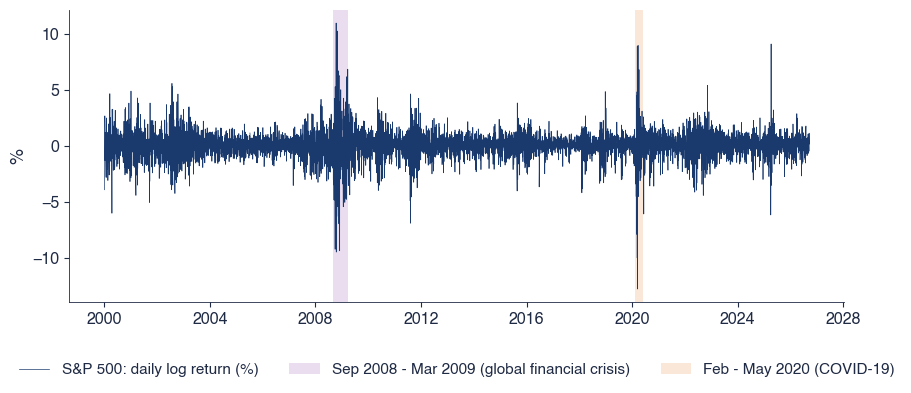

In [8]:
fig_returns(save=False)

## 2. Simulated ARCH(1) and GARCH(1,1) paths

- Three series with unconditional variance 1: i.i.d. Normal, ARCH(1) and GARCH(1,1); their sample kurtosis.

In [9]:
def simulate_garch(n, omega, alpha, beta=0.0, burn=500, seed=SEED, dist='normal', nu=5.0):
    """eps_t = sigma_t z_t, sigma_t^2 = omega + alpha eps_{t-1}^2 + beta sigma_{t-1}^2 (beta = 0: ARCH(1));
    z_t standard Normal or standardised Student-t; returns (eps, sigma)."""
    rng = np.random.default_rng(seed)
    m = n + burn
    z = rng.standard_normal(m) if dist == 'normal' else rng.standard_t(nu, m) * np.sqrt((nu - 2) / nu)
    s2 = np.empty(m)
    e = np.empty(m)
    s2[0] = omega / (1 - alpha - beta)
    e[0] = np.sqrt(s2[0]) * z[0]
    for t in range(1, m):
        s2[t] = omega + alpha * e[t - 1] ** 2 + beta * s2[t - 1]
        e[t] = np.sqrt(s2[t]) * z[t]
    return e[burn:], np.sqrt(s2[burn:])


def fig_simulated(n=1000, save=True):
    """Three paths with unconditional variance 1: i.i.d. Normal, ARCH(1) (omega = 0.5, alpha = 0.5) and
    GARCH(1,1) (omega = 0.02, alpha = 0.10, beta = 0.88, values typical of daily equity returns)."""
    rng = np.random.default_rng(SEED)
    paths = {'i.i.d. Normal(0, 1)': rng.standard_normal(n),
             'ARCH(1): omega = 0.5, alpha = 0.5': simulate_garch(n, 0.5, 0.5, 0.0, seed=SEED + 1)[0],
             'GARCH(1,1): omega = 0.02, alpha = 0.10, beta = 0.88': simulate_garch(n, 0.02, 0.10, 0.88, seed=SEED + 2)[0]}
    fig, axes = plt.subplots(3, 1, figsize=(11, 4.6), sharex=True, sharey=True)
    out = {}
    for ax, (lab, x), c in zip(axes, paths.items(), [st.MainBlue, st.IDAred, st.Forest]):
        ax.plot(np.arange(n), x, color=c, lw=0.7, label=lab)
        ax.set_ylabel('value')
        k = float(stats.kurtosis(x, fisher=False))
        out[lab.split(':')[0]] = {'sd': float(np.std(x)), 'kurt': k, 'max_abs': float(np.max(np.abs(x)))}
    axes[-1].set_xlabel('time t')
    st.fig_legend_bottom(fig, ncol=3, y=0.0)
    fig.tight_layout(rect=(0, 0.07, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch9_simulated')
    return out

{'i.i.d. Normal(0, 1)': {'sd': 1.0304556065650603,
  'kurt': 3.123049004729069,
  'max_abs': 3.747413858130894},
 'ARCH(1)': {'sd': 1.0233520220966699,
  'kurt': 4.910973401188952,
  'max_abs': 5.211144268406423},
 'GARCH(1,1)': {'sd': 0.9274374031785692,
  'kurt': 3.740525282563708,
  'max_abs': 3.543086950257758}}

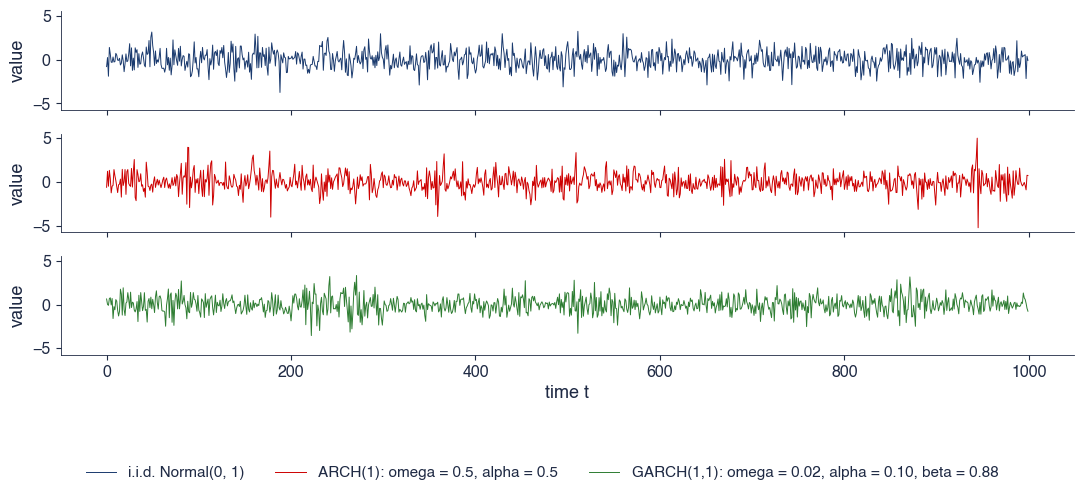

In [10]:
fig_simulated(save=False)

## 3. The likelihood

- ARCH(1): $\ell(\alpha)$ with $\omega = 1 - \alpha$ for $n = 100$ and $n = 1000$ (SFElikarch1).
- GARCH(1,1): contours of $\ell(\alpha, \beta)$ with variance targeting, $n = 500$ (SFElikgarch) and $n = 2000$.

In [11]:
def arch1_loglik(alpha, x):
    """Conditional Gaussian log-likelihood of ARCH(1) with omega = 1 - alpha (unconditional variance 1), as in
    SFElikarch1: l(alpha) = sum_{t>=2} [-0.5 ln s2_t - 0.5 x_t^2 / s2_t], s2_t = omega + alpha x_{t-1}^2."""
    s2 = (1 - alpha) + alpha * x[:-1] ** 2
    return float(np.sum(-0.5 * np.log(s2) - 0.5 * x[1:] ** 2 / s2))


def fig_lik_arch1(ns=(100, 1000), alpha0=0.5, save=True):
    """Log-likelihood of a simulated ARCH(1) (omega = 0.5, alpha = 0.5) as a function of alpha, for two sample sizes;
    each curve minus its maximum."""
    grid = np.linspace(0.05, 0.95, 181)
    fig, ax = plt.subplots(figsize=(10, 4.0))
    out = {}
    for n, c in zip(ns, [st.MainBlue, st.IDAred]):
        x = simulate_garch(n, 1 - alpha0, alpha0, 0.0, seed=SEED + n)[0]
        ll = np.array([arch1_loglik(a, x) for a in grid])
        res = optimize.minimize_scalar(lambda a: -arch1_loglik(a, x), bounds=(0.001, 0.999), method='bounded')
        ax.plot(grid, ll - ll.max(), color=c, lw=1.6, label=f'n = {n}: log-likelihood minus its maximum')
        ax.axvline(res.x, color=c, ls='--', lw=1.0, label=f'n = {n}: maximum at alpha = {res.x:.3f}')
        # curvature at the maximum: standard error from the observed information
        h = 1e-4
        d2 = (arch1_loglik(res.x + h, x) - 2 * arch1_loglik(res.x, x) + arch1_loglik(res.x - h, x)) / h ** 2
        out[str(n)] = {'alpha_hat': float(res.x), 'se': float(1 / np.sqrt(-d2))}
    ax.axvline(alpha0, color='black', ls=':', lw=1.2, label=f'true alpha = {alpha0}')
    ax.set_ylim(-40, 2)
    ax.set_xlabel('alpha')
    ax.set_ylabel('log-likelihood minus maximum')
    st.legend_outside_bottom(ax, ncol=2, y=-0.2)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch9_lik_arch1')
    return out


def garch_loglik_vt(a, b, x, s2bar):
    """Gaussian GARCH(1,1) log-likelihood with variance targeting omega = (1 - a - b) s2bar, as in SFElikgarch."""
    om = (1 - a - b) * s2bar
    s2 = np.empty(len(x))
    s2[0] = s2bar
    for t in range(1, len(x)):
        s2[t] = om + a * x[t - 1] ** 2 + b * s2[t - 1]
    return float(np.sum(-0.5 * np.log(s2[1:]) - 0.5 * x[1:] ** 2 / s2[1:]))


def fig_lik_garch(ns=(500, 2000), save=True):
    """Contour plots of the log-likelihood of a simulated GARCH(1,1) (omega = 0.1, alpha = 0.1, beta = 0.8) over a
    grid of (alpha, beta), with omega set by variance targeting, for n = 500 (as in SFElikgarch) and n = 2000."""
    A = np.linspace(0.01, 0.30, 59)
    B = np.linspace(0.50, 0.97, 48)
    fig, axes = plt.subplots(1, 2, figsize=(10, 4.6), sharey=True)
    out = {}
    cols = [st.Purple, st.MainBlue, st.Teal, st.Forest, st.Amber, st.Orange, st.IDAred]
    for ax, n in zip(axes, ns):
        x = simulate_garch(n, 0.1, 0.1, 0.8, seed=SEED + 7)[0]
        s2bar = float(np.var(x))
        L = np.full((len(B), len(A)), np.nan)
        for i, b in enumerate(B):
            for j, a in enumerate(A):
                if a + b < 0.995:
                    L[i, j] = garch_loglik_vt(a, b, x, s2bar)
        i, j = np.unravel_index(np.nanargmax(L), L.shape)
        lv = np.nanmax(L) - np.array([40, 20, 10, 5, 3, 2, 1])
        cs = ax.contour(A, B, L, levels=lv, colors=cols, linewidths=1.1)
        ax.clabel(cs, fmt=lambda v, m=np.nanmax(L): f'{v - m:.0f}', fontsize=8)
        ax.plot(A[j], B[i], 'o', color=st.IDAred, ms=8, label='maximum on the grid')
        ax.plot(0.1, 0.8, 'x', color='black', ms=9, mew=2, label='true values: alpha = 0.1, beta = 0.8')
        ax.plot(A, 1 - A, color=st.Purple, ls='--', lw=1.2, label='alpha + beta = 1 (IGARCH boundary)')
        ax.set_xlim(A[0], A[-1])
        ax.set_ylim(B[0], B[-1])
        ax.set_title(f'n = {n}: maximum at alpha = {A[j]:.2f}, beta = {B[i]:.2f}', loc='left', fontsize=11)
        ax.set_xlabel('alpha')
        out[str(n)] = {'a_hat': float(A[j]), 'b_hat': float(B[i])}
    axes[0].set_ylabel('beta')
    st.fig_legend_bottom(fig, ncol=3, y=0.0)
    fig.tight_layout(rect=(0, 0.08, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch9_lik_garch')
    return out

{'100': {'alpha_hat': 0.4321708014832945, 'se': 0.12654232891838452},
 '1000': {'alpha_hat': 0.4914830947353353, 'se': 0.035046208171455616}}

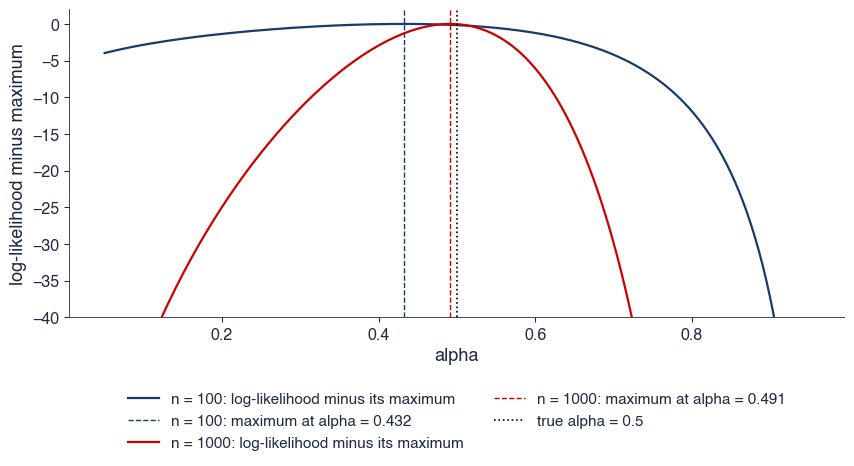

In [12]:
fig_lik_arch1(save=False)

{'500': {'a_hat': 0.045, 'b_hat': 0.63},
 '2000': {'a_hat': 0.09999999999999998, 'b_hat': 0.78}}

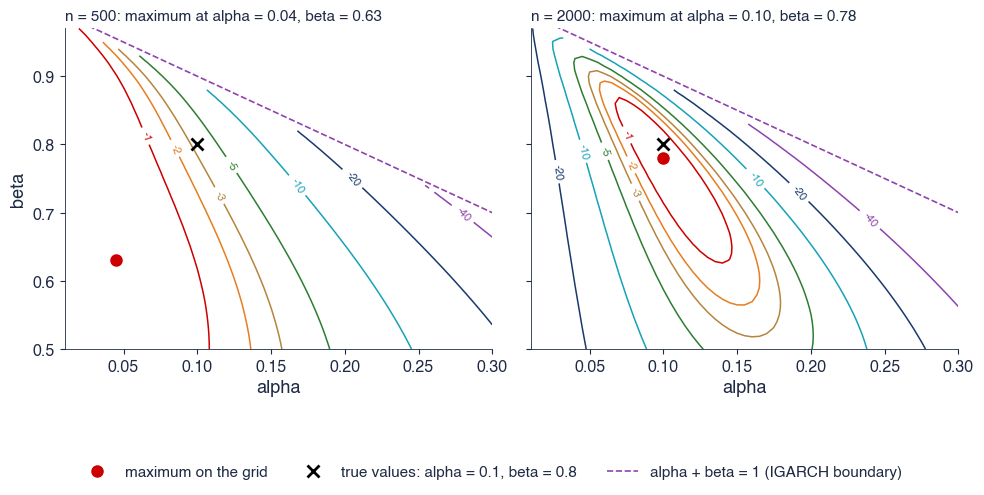

In [13]:
fig_lik_garch(save=False)

## 4. Estimation: ARCH(q) against GARCH(1,1); step by step against the `arch` package

- ARCH(1), ARCH(5), ARCH(10) and GARCH(1,1) with Normal innovations: log-likelihood, AIC, BIC.
- The Gaussian GARCH(1,1) estimated by minimising $-\ell(\theta)$ with scipy, and with `arch`; classic and robust standard errors.
- Normal, Student-t and skewed-t innovations; QQ plots of the standardised residuals.

In [14]:
def arch_q_table(k='sp500'):
    """ARCH(1), ARCH(5), ARCH(10) and GARCH(1,1), all Gaussian: log-likelihood, AIC, BIC, sum of the ARCH terms."""
    r = returns(k)
    out = {}
    for lab, kw in [('ARCH(1)', dict(vol='ARCH', p=1)), ('ARCH(5)', dict(vol='ARCH', p=5)),
                    ('ARCH(10)', dict(vol='ARCH', p=10)), ('GARCH(1,1)', dict(vol='GARCH'))]:
        res = fit(r, dist='normal', **kw)
        p = res.params
        out[lab] = {'k': int(len(p)), 'loglik': float(res.loglikelihood), 'aic': float(res.aic), 'bic': float(res.bic),
                    'sum_alpha': float(sum(v for n, v in p.items() if n.startswith('alpha'))),
                    'pers': float(sum(v for n, v in p.items() if n.startswith(('alpha', 'beta'))))}
    return out


def garch11_negloglik(theta, x):
    """Minus the Gaussian log-likelihood of r_t = mu + eps_t, GARCH(1,1); sigma_1^2 = sample variance."""
    mu, om, a, b = theta
    if om <= 0 or a < 0 or b < 0 or a + b >= 1:
        return 1e10
    e = x - mu
    s2 = np.empty(len(x))
    s2[0] = np.var(x)
    for t in range(1, len(x)):
        s2[t] = om + a * e[t - 1] ** 2 + b * s2[t - 1]
    return 0.5 * np.sum(np.log(2 * np.pi) + np.log(s2) + e ** 2 / s2)


def fit_step_by_step(r):
    """Gaussian GARCH(1,1) estimated by numerical optimisation of the log-likelihood (scipy, L-BFGS-B), with
    classic standard errors from the inverse of the numerical Hessian."""
    x = np.asarray(r, float)
    v = np.var(x)
    th0 = np.array([x.mean(), 0.05 * v, 0.08, 0.90])
    bnds = [(None, None), (1e-6, None), (1e-6, 0.999), (1e-6, 0.999)]
    cons = [{'type': 'ineq', 'fun': lambda t: 0.9999 - t[2] - t[3]}]       # alpha + beta < 1
    res = optimize.minimize(garch11_negloglik, th0, args=(x,), method='SLSQP', bounds=bnds, constraints=cons,
                            options={'maxiter': 1000, 'ftol': 1e-10})
    th = res.x
    from statsmodels.tools.numdiff import approx_hess
    H = approx_hess(th, garch11_negloglik, args=(x,))
    se = np.sqrt(np.diag(np.linalg.inv(H)))
    return {'params': dict(zip(['mu', 'omega', 'alpha[1]', 'beta[1]'], map(float, th))),
            'se': dict(zip(['mu', 'omega', 'alpha[1]', 'beta[1]'], map(float, se))), 'loglik': float(-res.fun)}


def estimation_sp500(k='sp500'):
    """S&P 500 GARCH(1,1): Normal innovations step by step and with arch (classic and robust standard errors);
    Student-t and skewed-t innovations with arch."""
    r = returns(k)
    out = {'step': fit_step_by_step(r)}
    rn = fit(r, dist='normal')
    rc = fit(r, dist='normal', cov_type='classic')
    out['normal'] = summary(rn, r)
    out['normal']['se_classic'] = {n: float(v) for n, v in rc.std_err.items()}
    for d in ['t', 'skewt']:
        out[d] = summary(fit(r, dist=d), r)
    z = rn.std_resid.dropna()
    out['kurt_r'] = float(stats.kurtosis(r, fisher=False))
    out['kurt_z'] = float(stats.kurtosis(z, fisher=False))
    out['skew_z'] = float(stats.skew(z))
    return out


def fig_qq(k='sp500', save=True):
    """QQ plots of the standardised residuals: GARCH-N against the Normal, GARCH-t against the standardised t."""
    r = returns(k)
    rn, rt = fit(r, dist='normal'), fit(r, dist='t')
    nu = rt.params['nu']
    fig, axes = plt.subplots(1, 2, figsize=(10, 4.4))
    out = {}
    for ax, res, lab, ppf, c in [(axes[0], rn, 'GARCH(1,1)-N residuals against the Normal', stats.norm.ppf, st.MainBlue),
                                 (axes[1], rt, f'GARCH(1,1)-t residuals against the standardised t({nu:.1f})',
                                  lambda u: stats.t.ppf(u, nu) * np.sqrt((nu - 2) / nu), st.IDAred)]:
        z = np.sort(res.std_resid.dropna().values)
        u = (np.arange(1, len(z) + 1) - 0.5) / len(z)
        qth = ppf(u)
        ax.scatter(qth, z, s=5, color=c, alpha=0.6, label=lab)
        lim = [min(qth.min(), z.min()), max(qth.max(), z.max())]
        ax.plot(lim, lim, color='black', lw=1.0, ls='--', label='45-degree line' if c == st.MainBlue else '_')
        ax.set_xlabel('theoretical quantile')
        ax.set_ylabel('sample quantile')
        out[lab.split()[0]] = {'q001': float(np.quantile(z, 0.001)), 'th001': float(ppf(0.001))}
    st.fig_legend_bottom(fig, ncol=1, y=0.0)
    fig.tight_layout(rect=(0, 0.14, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch9_qq')
    return {'nu': float(nu), 'q': out}

In [15]:
pd.DataFrame(arch_q_table()).T.round(3)

,k,loglik,aic,bic,sum_alpha,pers
ARCH(1),3.0,-10305.524,20617.048,20637.484,0.394,0.394
ARCH(5),7.0,-9340.529,18695.057,18742.741,0.816,0.816
ARCH(10),12.0,-9227.647,18479.295,18561.038,0.849,0.849
"GARCH(1,1)",4.0,-9217.992,18443.983,18471.231,0.121,0.980


In [16]:
est = estimation_sp500()
pd.DataFrame({'step by step': est['step']['params'], 'SE (step by step)': est['step']['se'], 'arch': est['normal']['params'], 'classic SE': est['normal']['se_classic'], 'robust SE': est['normal']['se']}).round(4)

,step by step,SE (step by step),arch,classic SE,robust SE
mu,0.0614,0.0098,0.0615,0.0098,0.0100
omega,0.0253,0.0030,0.0254,0.0030,0.0048
alpha[1],0.1205,0.0086,0.1206,0.0086,0.0118
beta[1],0.8600,0.0091,0.8599,0.0091,0.0125


In [17]:
pd.DataFrame({d: {**est[d]['params'], 'loglik': est[d]['loglik'], 'persistence': est[d]['pers']} for d in ['normal', 't', 'skewt']}).round(4)

,normal,t,skewt
mu,0.0615,0.0788,0.0591
omega,0.0254,0.0157,0.0153
alpha[1],0.1206,0.1226,0.1205
beta[1],0.8599,0.8721,0.8720
loglik,-9217.9915,-9062.4733,-9038.4349
persistence,0.9805,0.9947,0.9925
nu,NaN,6.2562,NaN
eta,NaN,NaN,6.9176
lambda,NaN,NaN,-0.1142


{'nu': 6.256190304034686,
 'q': {'GARCH(1,1)-N': {'q001': -4.814994199582458,
   'th001': -3.090232306167813},
  'GARCH(1,1)-t': {'q001': -4.790511893599644, 'th001': -4.191055602139561}}}

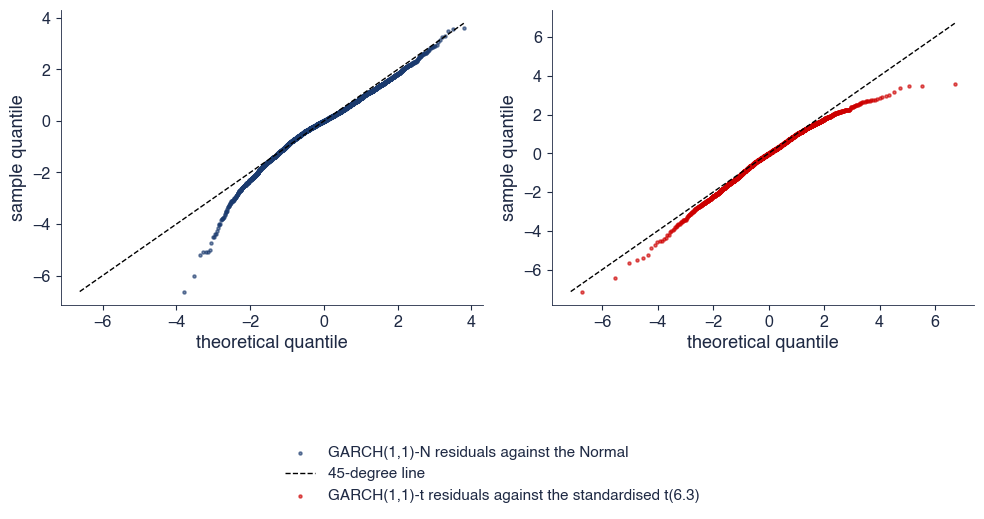

In [18]:
fig_qq(save=False)

## 5. GARCH(1,1)-t in six markets

- Parameters, persistence, half-life, long-run and sample volatility; Bitcoin is estimated on the boundary $\alpha + \beta = 1$ (IGARCH).
- Annualised conditional volatility (SFEvolgarchest) and the decay of a variance shock.

In [19]:
def markets_table(names=ASSETS):
    """GARCH(1,1)-t for each series: parameters, robust standard errors, persistence, half-life, volatility."""
    return {k: summary(fit(returns(k), dist='t'), returns(k)) for k in names}


def fig_vol(names=('sp500', 'dax'), fname='sfm_ch9_vol_sp500_dax', save=True):
    """Annualised GARCH(1,1)-t conditional volatility, with the 2008 and 2020 episodes shaded (as in SFEvolgarchest)."""
    fig, axes = plt.subplots(len(names), 1, figsize=(10, 5.4), sharex=False)
    out = {}
    for ax, k in zip(np.atleast_1d(axes), names):
        r = returns(k)
        res = fit(r, dist='t')
        ann = np.sqrt(periods_per_year(r))
        v = res.conditional_volatility * ann
        ax.plot(v.index, v.values, color=COLORS[k], lw=0.9, label=f'{NAME[k]}: GARCH(1,1)-t volatility, annualised (%)')
        ax.axhline(r.std() * ann, color='black', ls='--', lw=0.9, label=f'{NAME[k]}: sample volatility, annualised (%)' if k == names[0] else '_')
        for (a, b), c in zip(EPISODES.values(), [st.Purple, st.Orange]):
            if pd.Timestamp(a) < r.index[0]:
                continue
            ax.axvspan(pd.Timestamp(a), pd.Timestamp(b), color=c, alpha=0.15, lw=0)
        ax.set_ylabel('% per year')
        out[k] = {'last': float(v.iloc[-1]), 'max': float(v.max()), 'date_max': v.idxmax().date().isoformat(),
                  'min': float(v.min()), 'median': float(v.median())}
        for e, (a, b) in EPISODES.items():
            w = v.loc[a:b]
            if len(w):
                out[k][f'peak{e}'] = float(w.max())
                out[k][f'date{e}'] = w.idxmax().date().isoformat()
    h, l = [], []
    for ax in np.atleast_1d(axes):
        for hh, ll in zip(*ax.get_legend_handles_labels()):
            if not ll.startswith('_'):
                h.append(hh)
                l.append(ll)
    h += [plt.Rectangle((0, 0), 1, 1, color=st.Purple, alpha=0.3), plt.Rectangle((0, 0), 1, 1, color=st.Orange, alpha=0.3)]
    l += ['Sep 2008 - Mar 2009 (global financial crisis)', 'Feb - May 2020 (COVID-19)']
    st.fig_legend_bottom(fig, h, l, ncol=2, y=0.0)
    fig.tight_layout(rect=(0, 0.12, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig(fname)
    return out


def fig_persistence(T=None, save=True, horizon=250):
    """Share of a variance shock left after h days, persistence^h, with the half-lives marked."""
    T = T or markets_table()
    fig, ax = plt.subplots(figsize=(10, 4.0))
    h = np.arange(horizon + 1)
    for k, d in T.items():
        lab = (f"{NAME[k]}: alpha + beta = {d['pers']:.3f}, half-life {d['hl']:.0f} days" if d['pers'] < 0.9995
               else f"{NAME[k]}: alpha + beta = 1 (IGARCH), no half-life")
        ax.plot(h, d['pers'] ** h, color=COLORS[k], lw=1.5, label=lab)
    ax.axhline(0.5, color='black', ls=':', lw=1.0, label='half of the shock')
    ax.set_xlabel('days after the shock, h')
    ax.set_ylabel('share of the shock left')
    ax.set_ylim(0, 1.02)
    st.legend_outside_bottom(ax, ncol=2, y=-0.2)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch9_persistence')

In [20]:
T = markets_table()
pd.DataFrame({NAME[k]: {**v['params'], 'persistence': v['pers'], 'half-life': v['hl'], 'long-run vol': v.get('vol_lr'), 'sample vol': v['vol_sample']} for k, v in T.items()}).T.round(4)

,mu,omega,alpha[1],beta[1],nu,persistence,half-life,long-run vol,sample vol
S&P 500,0.0788,0.0157,0.1226,0.8721,6.2562,0.9947,1.307335e+02,2.733360e+01,19.2338
DAX,0.0805,0.0206,0.0971,0.8951,7.0790,0.9922,8.846740e+01,2.590720e+01,22.4385
BET,0.0832,0.0448,0.1916,0.7991,5.0112,0.9907,7.427770e+01,3.470540e+01,22.1063
Bitcoin,0.1111,0.1937,0.1087,0.8913,3.1806,1.0000,2.044709e+11,4.568810e+06,66.6149
Banca Transilvania,0.1036,0.1299,0.1389,0.8241,4.9148,0.9630,1.836020e+01,2.819420e+01,26.4740
OMV Petrom,0.0840,0.1648,0.1354,0.8071,4.8087,0.9425,1.170270e+01,2.558250e+01,24.5121


{'sp500': {'last': 11.919284831613588,
  'max': 111.02616503718859,
  'date_max': '2020-03-17',
  'min': 6.245704922834574,
  'median': 14.269224853364733,
  'peak2008': 92.99976329371611,
  'date2008': '2008-10-16',
  'peak2020': 111.02616503718859,
  'date2020': '2020-03-17'},
 'dax': {'last': 12.969804893204962,
  'max': 81.56923776497017,
  'date_max': '2020-03-25',
  'min': 8.252654735536538,
  'median': 17.698584499674702,
  'peak2008': 80.39816348957594,
  'date2008': '2008-10-29',
  'peak2020': 81.56923776497017,
  'date2020': '2020-03-25'}}

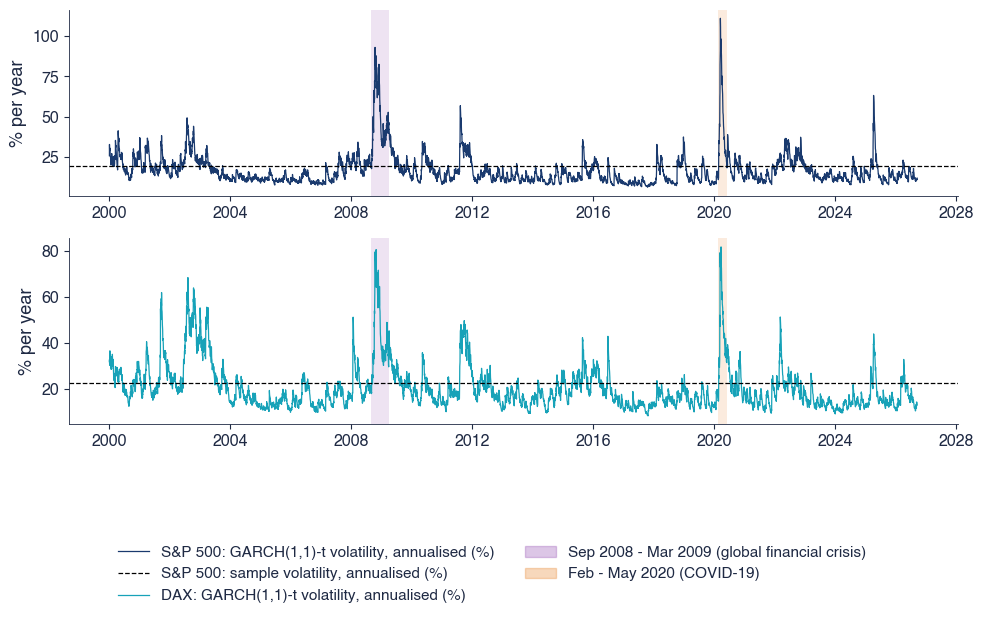

In [21]:
fig_vol(('sp500', 'dax'), 'sfm_ch9_vol_sp500_dax', save=False)

{'bet': {'last': 26.390112895647338,
  'max': 116.87640901132798,
  'date_max': '2008-10-15',
  'min': 8.196253713401468,
  'median': 15.554471185815022,
  'peak2008': 116.87640901132798,
  'date2008': '2008-10-15',
  'peak2020': 87.77277153067078,
  'date2020': '2020-03-18'},
 'btc': {'last': 42.40808717015003,
  'max': 300.8742282390173,
  'date_max': '2020-03-13',
  'min': 27.59141520796791,
  'median': 58.73241441266687,
  'peak2020': 300.8742282390173,
  'date2020': '2020-03-13'}}

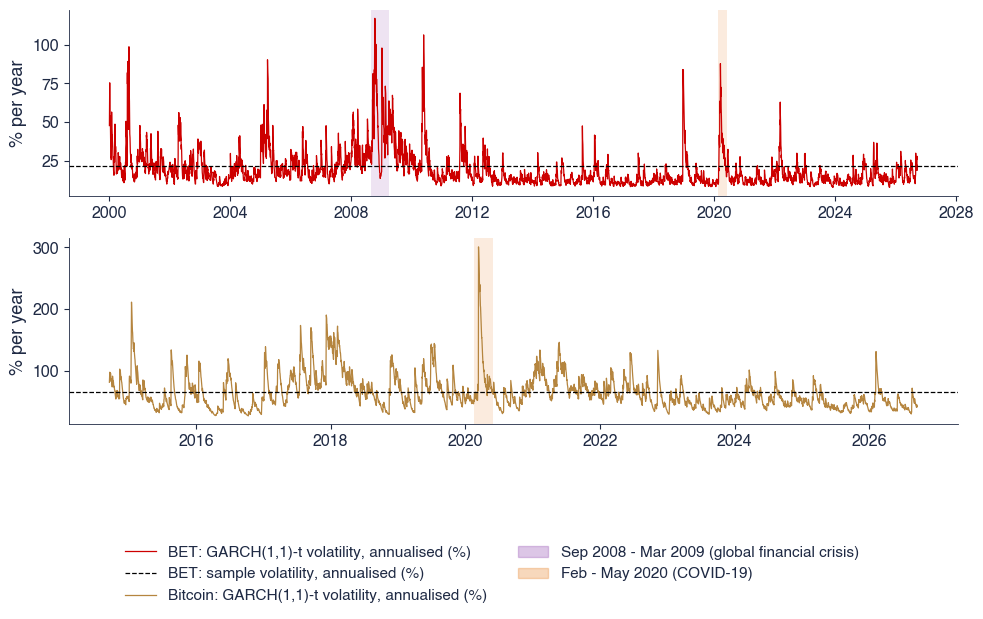

In [22]:
fig_vol(('bet', 'btc'), 'sfm_ch9_vol_bet_btc', save=False)

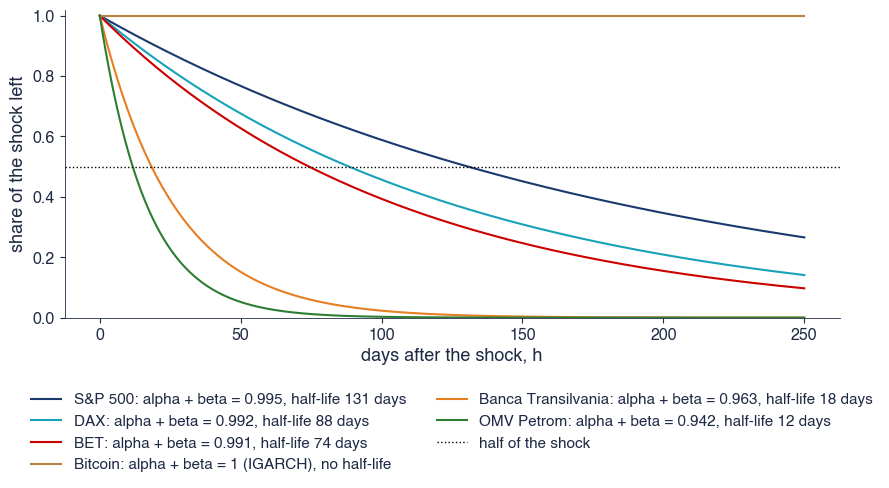

In [23]:
fig_persistence(T, save=False)

## 6. Asymmetry: GJR-GARCH, EGARCH and the news impact curve

- News impact curves of GARCH, GJR and EGARCH (Student-t) and a kernel estimate of $E[r_t^2 \mid r_{t-1}]$.
- GJR $\gamma$, the likelihood-ratio test against GARCH, EGARCH $\gamma$, the sign-bias test.

In [24]:
def news_impact(res, eps, s2bar):
    """sigma_t^2 as a function of the shock eps_{t-1}, with sigma_{t-1}^2 fixed at s2bar (Engle and Ng, 1993)."""
    p = res.params
    if res.model.volatility.__class__.__name__ == 'EGARCH':
        z = eps / np.sqrt(s2bar)
        return np.exp(p['omega'] + p['alpha[1]'] * (np.abs(z) - np.sqrt(2 / np.pi)) + p['gamma[1]'] * z
                      + p['beta[1]'] * np.log(s2bar))
    return p['omega'] + (p['alpha[1]'] + p.get('gamma[1]', 0.0) * (eps < 0)) * eps ** 2 + p['beta[1]'] * s2bar


def kernel_nic(r, grid, h=None):
    """Nadaraya-Watson estimate of E[r_t^2 | r_{t-1} = x] with a Gaussian kernel (the idea of SFENewsImpactCurve);
    bandwidth half a standard deviation of the returns."""
    x, y = r.values[:-1], r.values[1:] ** 2
    h = h or 0.5 * np.std(x)
    w = stats.norm.pdf((grid[:, None] - x[None, :]) / h)
    return (w * y).sum(1) / w.sum(1), h


def fig_nic(names=('sp500', 'btc'), save=True):
    """News impact curves of GARCH-t, GJR-t and EGARCH-t and a kernel estimate, for two series."""
    fig, axes = plt.subplots(1, 2, figsize=(10, 4.4))
    out = {}
    for ax, k in zip(axes, names):
        r = returns(k)
        s2bar = float(r.var())
        lo, hi = np.quantile(r, [0.01, 0.99])
        g = np.linspace(lo, hi, 201)
        for vol, o, lab, c in [('GARCH', 0, 'GARCH(1,1)-t', st.MainBlue), ('GARCH', 1, 'GJR-GARCH(1,1)-t', st.IDAred),
                               ('EGARCH', 0, 'EGARCH(1,1)-t', st.Forest)]:
            res = fit(r, vol=vol, o=o, dist='t')
            ax.plot(g, news_impact(res, g, s2bar), color=c, lw=1.6, label=lab)
        kn, h = kernel_nic(r, g)
        ax.plot(g, kn, color=st.Amber, lw=1.4, ls='--', label='kernel estimate of E[r(t)^2 | r(t-1)]')
        ax.set_title(NAME[k], loc='left', fontsize=12)
        ax.set_xlabel('shock yesterday, eps(t-1) (%)')
        ax.set_ylabel('variance today (%^2)')
        rg = fit(r, o=1, dist='t')
        out[k] = {'ratio_gjr': float(news_impact(rg, np.array([-2.0]), s2bar)[0] / news_impact(rg, np.array([2.0]), s2bar)[0]),
                  'h': float(h)}
    st.fig_legend_bottom(fig, ncol=2, y=0.0)
    fig.tight_layout(rect=(0, 0.13, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch9_nic')
    return out


def sign_bias_test(z, eps):
    """Engle-Ng (1993) sign-bias tests: z_t^2 on a constant, S-_{t-1}, S-_{t-1} eps_{t-1}, S+_{t-1} eps_{t-1};
    t statistics and the joint test T R^2 ~ chi2(3)."""
    d = pd.concat([pd.Series(np.asarray(z)), pd.Series(np.asarray(eps))], axis=1, keys=['z', 'e']).dropna()
    zz, e = d['z'].values, d['e'].values
    y = zz[1:] ** 2
    el = e[:-1]
    sneg = (el < 0).astype(float)
    X = np.column_stack([np.ones_like(el), sneg, sneg * el, (1 - sneg) * el])
    ols = sm.OLS(y, X).fit()
    joint = len(y) * ols.rsquared
    return {'sign_t': float(ols.tvalues[1]), 'neg_t': float(ols.tvalues[2]), 'pos_t': float(ols.tvalues[3]),
            'joint': float(joint), 'joint_p': float(stats.chi2.sf(joint, 3))}


def asym_table(names=ASSETS):
    """GJR-GARCH(1,1)-t and EGARCH(1,1)-t: the asymmetry parameter gamma, its robust t statistic, the likelihood
    ratio test of GJR against GARCH, and the sign-bias test on the GARCH-t residuals."""
    out = {}
    for k in names:
        r = returns(k)
        rg, rj, re_ = fit(r, dist='t'), fit(r, o=1, dist='t'), fit(r, vol='EGARCH', dist='t')
        lr = 2 * (rj.loglikelihood - rg.loglikelihood)
        sb = sign_bias_test(rg.std_resid, rg.resid)
        out[k] = {'gjr_gamma': float(rj.params['gamma[1]']), 'gjr_t': float(rj.tvalues['gamma[1]']),
                  'gjr_alpha': float(rj.params['alpha[1]']), 'gjr_beta': float(rj.params['beta[1]']),
                  'gjr_pers': persistence(rj), 'lr': float(lr), 'lr_p': float(stats.chi2.sf(lr, 1)),
                  'eg_gamma': float(re_.params['gamma[1]']), 'eg_t': float(re_.tvalues['gamma[1]']),
                  'eg_beta': float(re_.params['beta[1]']), 'sb': sb,
                  'bic_g': float(rg.bic), 'bic_j': float(rj.bic), 'bic_e': float(re_.bic)}
    return out

{'sp500': {'ratio_gjr': 1.6242323039138316, 'h': 0.6065141763352633},
 'btc': {'ratio_gjr': 0.9953121592606824, 'h': 1.7420823202296205}}

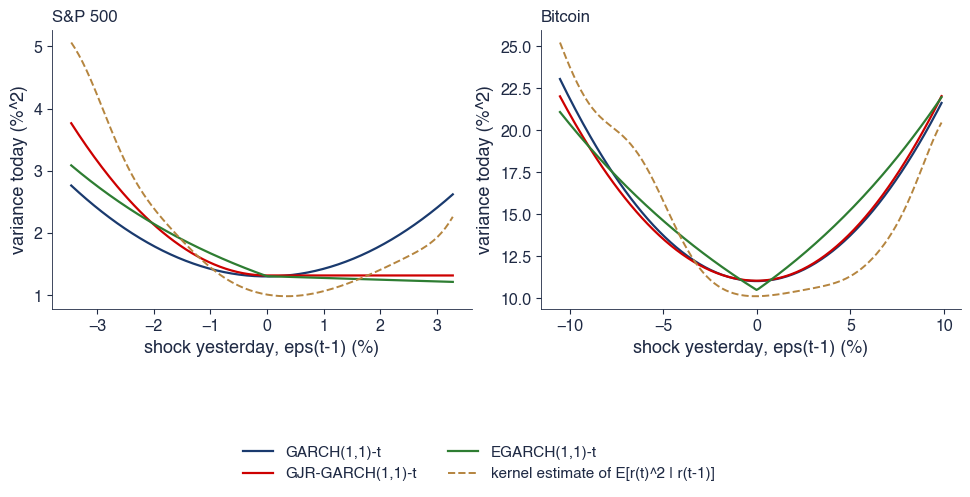

In [25]:
fig_nic(save=False)

In [26]:
at = asym_table()
pd.DataFrame({NAME[k]: {c: v[c] for c in ['gjr_alpha', 'gjr_gamma', 'gjr_t', 'lr', 'lr_p', 'eg_gamma', 'eg_t']} for k, v in at.items()}).T.round(3)

,gjr_alpha,gjr_gamma,gjr_t,lr,lr_p,eg_gamma,eg_t
S&P 500,0.000,0.205,10.028,235.653,0.000,-0.165,-15.203
DAX,0.000,0.163,8.726,204.452,0.000,-0.133,-11.782
BET,0.172,0.043,2.051,4.926,0.026,-0.028,-2.631
Bitcoin,0.113,-0.013,-0.721,0.662,0.416,0.015,1.181
Banca Transilvania,0.101,0.065,2.711,7.812,0.005,-0.040,-2.996
OMV Petrom,0.117,0.033,1.387,1.736,0.188,-0.027,-1.865


## 7. Diagnostics and model selection

- Ljung–Box and ARCH-LM tests on the standardised residuals; the ACF of $r_t^2$ against that of $\hat z_t^2$.
- Nine models compared by AIC and BIC.

In [27]:
def ljung_box(x, lags=10):
    """Ljung-Box Q(lags) and its p-value."""
    lb = acorr_ljungbox(pd.Series(np.asarray(x)).dropna(), lags=[lags])
    return float(lb['lb_stat'].iloc[0]), float(lb['lb_pvalue'].iloc[0])


def diagnostics(k='sp500'):
    """Ljung-Box Q(10) of r, r^2, z, z^2 and ARCH-LM(5) of z, for GARCH-N and GARCH-t."""
    r = returns(k)
    out = {'r': ljung_box(r), 'r2': ljung_box(r ** 2), 'archlm_r': list(map(float, het_arch(r.values, nlags=5)[:2]))}
    for d in ['normal', 't']:
        z = fit(r, dist=d).std_resid.dropna()
        out[d] = {'z': ljung_box(z), 'z2': ljung_box(z ** 2), 'archlm': list(map(float, het_arch(z.values, nlags=5)[:2]))}
    return out


def diag_markets(names=ASSETS):
    """Ljung-Box Q(10) of r^2 and of z^2 (GARCH-t) for each series."""
    out = {}
    for k in names:
        r = returns(k)
        z = fit(r, dist='t').std_resid.dropna()
        out[k] = {'r2': ljung_box(r ** 2), 'z2': ljung_box(z ** 2), 'z': ljung_box(z)}
    return out


def fig_acf_diag(k='sp500', nlags=50, save=True):
    """ACF of squared returns and of squared standardised residuals (GARCH-t), with the 95% band."""
    r = returns(k)
    z = fit(r, dist='t').std_resid.dropna()
    from statsmodels.tsa.stattools import acf as sacf
    a1 = sacf(r ** 2, nlags=nlags, fft=True)[1:]
    a2 = sacf(z ** 2, nlags=nlags, fft=True)[1:]
    lags = np.arange(1, nlags + 1)
    band = 1.96 / np.sqrt(len(r))
    fig, ax = plt.subplots(figsize=(10, 3.9))
    ax.bar(lags - 0.2, a1, width=0.4, color=COLORS[k], label=f'{NAME[k]}: squared returns')
    ax.bar(lags + 0.2, a2, width=0.4, color=st.IDAred, label=f'{NAME[k]}: squared standardised residuals, GARCH(1,1)-t')
    ax.axhline(band, color='black', ls='--', lw=0.9, label='95% band, +/- 1.96/sqrt(T)')
    ax.axhline(-band, color='black', ls='--', lw=0.9)
    ax.axhline(0, color='black', lw=0.6)
    ax.set_xlabel('lag k (days)')
    ax.set_ylabel('autocorrelation')
    st.legend_outside_bottom(ax, ncol=2, y=-0.2)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch9_acf_diag')
    return {'a1_1': float(a1[0]), 'a1_50': float(a1[-1]), 'a2_1': float(a2[0]), 'max_a2': float(np.max(np.abs(a2))),
            'band': float(band)}


def model_selection(k='sp500'):
    """Nine models (GARCH, GJR, EGARCH x Normal, t, skewed t): log-likelihood, number of parameters, AIC, BIC."""
    r = returns(k)
    rows = []
    for vol, o, vlab in [('GARCH', 0, 'GARCH'), ('GARCH', 1, 'GJR'), ('EGARCH', 0, 'EGARCH')]:
        for d, dlab in [('normal', 'Normal'), ('t', 't'), ('skewt', 'skewed t')]:
            res = fit(r, vol=vol, o=o, dist=d)
            rows.append({'model': vlab, 'dist': dlab, 'k': int(len(res.params)), 'loglik': float(res.loglikelihood),
                         'aic': float(res.aic), 'bic': float(res.bic)})
    df = pd.DataFrame(rows)
    df['d_aic'] = df['aic'] - df['aic'].min()
    df['d_bic'] = df['bic'] - df['bic'].min()
    return df

In [28]:
diagnostics()

{'r': (96.26294643822116, 3.041604310685084e-16),
 'r2': (6132.817239087847, 0.0),
 'archlm_r': [1678.8629202839443, 0.0],
 'normal': {'z': (21.198333015390183, 0.01975224870824878),
  'z2': (16.396025134533204, 0.08884310339354372),
  'archlm': [8.035876309656226, 0.15426946594654106]},
 't': {'z': (21.858114862057924, 0.01584395893404898),
  'z2': (13.610348630216418, 0.19151799821764812),
  'archlm': [5.7985659431407, 0.3263154084163243]}}

{'a1_1': 0.31316071975401993,
 'a1_50': 0.052766846997660016,
 'a2_1': -0.004936638305348343,
 'max_a2': 0.027820113205218946,
 'band': 0.02392023284731494}

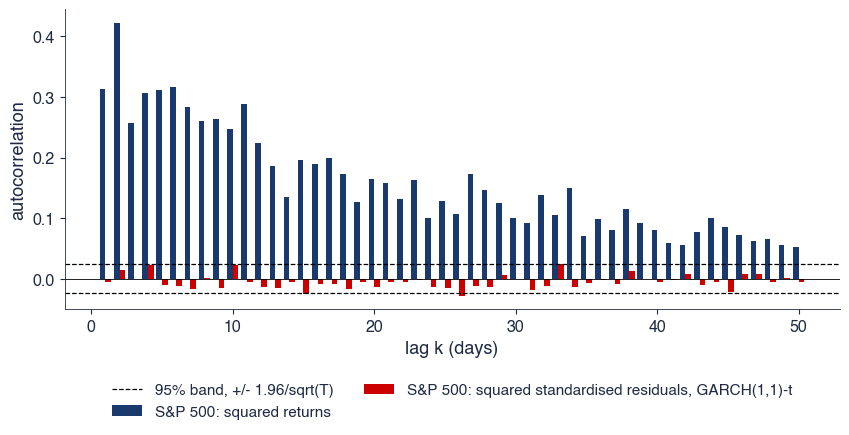

In [29]:
fig_acf_diag(save=False)

In [30]:
model_selection().round(1)

,model,dist,k,loglik,aic,bic,d_aic,d_bic
0,GARCH,Normal,4,-9218.0,18444.0,18471.2,669.4,648.9
1,GARCH,t,5,-9062.5,18134.9,18169.0,360.3,346.7
2,GARCH,skewed t,6,-9038.4,18088.9,18129.7,314.2,307.4
3,GJR,Normal,5,-9086.5,18183.0,18217.1,408.4,394.7
4,GJR,t,6,-8944.6,17901.3,17942.2,126.7,119.9
5,GJR,skewed t,7,-8905.1,17824.3,17871.9,49.6,49.6
6,EGARCH,Normal,5,-9075.6,18161.1,18195.2,386.5,372.9
7,EGARCH,t,6,-8922.1,17856.2,17897.1,81.6,74.8
8,EGARCH,skewed t,7,-8880.3,17774.6,17822.3,0.0,0.0


## 8. Forecasts and the term structure of volatility

- $E_t[\sigma_{t+h}^2] = \bar\sigma^2 + (\alpha + \beta)^{h-1}(\sigma_{t+1}^2 - \bar\sigma^2)$; forecasts made on a calm day, at the COVID-19 peak and on the last day.

In [31]:
def garch_path_forecast(res, r, date, horizon=250):
    """Multi-step GARCH(1,1) variance forecasts made at the end of `date`:
    sigma^2_{t+h} = s2bar + (alpha + beta)^(h-1) (sigma^2_{t+1} - s2bar), s2bar = omega / (1 - alpha - beta)."""
    p = res.params
    pers = p['alpha[1]'] + p['beta[1]']
    s2bar = p['omega'] / (1 - pers)
    i = r.index.get_loc(pd.Timestamp(date))
    s2t = res.conditional_volatility.iloc[i] ** 2
    e = r.iloc[i] - p['mu']
    s2next = p['omega'] + p['alpha[1]'] * e ** 2 + p['beta[1]'] * s2t
    h = np.arange(1, horizon + 1)
    return s2bar + pers ** (h - 1) * (s2next - s2bar), s2bar, s2next


def fig_term_structure(k='sp500', save=True, horizon=250):
    """Forecasts of the daily volatility h days ahead (annualised) and the average volatility over the next h days,
    made on a calm day, at the COVID-19 peak and on the last day of the data."""
    r = returns(k)
    res = fit(r, dist='t')
    ann = periods_per_year(r)
    dates = TERM_DATES + [r.index[-1].date().isoformat()]
    fig, ax = plt.subplots(figsize=(10, 4.0))
    out = {}
    h = np.arange(1, horizon + 1)
    for d, c in zip(dates, [st.Forest, st.IDAred, st.MainBlue]):
        f, s2bar, s2n = garch_path_forecast(res, r, d, horizon)
        avg = np.sqrt(np.cumsum(f) / h * ann)
        ax.plot(h, np.sqrt(f * ann), color=c, lw=1.6, label=f'forecast made on {d}: daily volatility on day t+h')
        ax.plot(h, avg, color=c, lw=1.2, ls='--', label=f'forecast made on {d}: average volatility over the next h days')
        out[d] = {'h1': float(np.sqrt(f[0] * ann)), 'h10': float(np.sqrt(f[9] * ann)), 'h22': float(np.sqrt(f[21] * ann)),
                  'h250': float(np.sqrt(f[-1] * ann)), 'avg10': float(avg[9]), 'avg22': float(avg[21]), 'avg250': float(avg[-1]),
                  's2next': float(s2n), 'sum10': float(np.sum(f[:10]))}
    ax.axhline(np.sqrt(s2bar * ann), color='black', ls=':', lw=1.0, label='long-run volatility')
    ax.set_xlabel('horizon h (trading days)')
    ax.set_ylabel('% per year')
    st.legend_outside_bottom(ax, ncol=2, y=-0.2)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch9_term_structure')
    out['lr'] = float(np.sqrt(s2bar * ann))
    out['s2bar'] = float(s2bar)
    out['params'] = {n: float(v) for n, v in res.params.items()}
    return out

{'2017-11-03': {'h1': 7.261996292868396,
  'h10': 9.224592184143226,
  'h22': 11.220606233048011,
  'h250': 23.699450738910222,
  'avg10': 8.308381932306077,
  'avg22': 9.485025036799806,
  'avg250': 19.01079062001671,
  's2next': 0.20976027102747713,
  'sum10': 2.7456431720361016},
 '2020-03-16': {'h1': 111.0261650371886,
  'h10': 108.5689992481071,
  'h22': 105.38829435472229,
  'h250': 61.96664291521849,
  'avg10': 109.79577085330195,
  'avg22': 108.19413778820777,
  'avg250': 84.73090025147663,
  's2next': 49.02999713745981,
  'sum10': 479.4931574877072},
 '2026-09-18': {'h1': 11.317806804136978,
  'h10': 12.527484606780346,
  'h22': 13.903888405444299,
  'h250': 24.120330504711408,
  'avg10': 11.942247041519673,
  'avg22': 12.699672661090961,
  'avg250': 20.08154546635838,
  's2next': 0.50949009133598,
  'sum10': 5.672614771729694},
 'lr': 27.333551730323386,
 's2bar': 2.9716887844129496,
 'params': {'mu': 0.07882493250433978,
  'omega': 0.01571415572903517,
  'alpha[1]': 0.122573

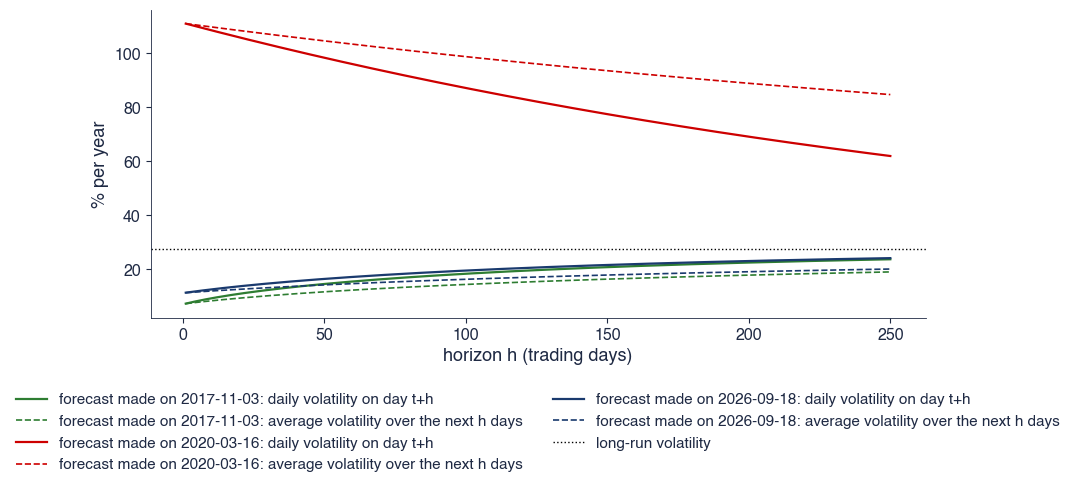

In [32]:
fig_term_structure(save=False)

## 9. Out-of-sample comparison with EWMA, and VaR 1%

- One-day forecasts since 2015: GARCH-t and GJR-t re-estimated every 250 days, EWMA with $\lambda = 0.94$.
- QLIKE loss $r_t^2/h_t + \ln h_t$ (Patton, 2011) and the Diebold–Mariano test; VaR 1% exceedances (a preview of Chapter 10).

In [33]:
def ewma_variance(r, lam=LAMBDA, init=250):
    """EWMA variance forecast for day t made at t-1 (Chapter 8): h_t = lam h_{t-1} + (1 - lam) r_{t-1}^2."""
    x = np.asarray(r, float)
    h = np.empty(len(x))
    h[0] = np.mean(x[:init] ** 2)
    for t in range(1, len(x)):
        h[t] = lam * h[t - 1] + (1 - lam) * x[t - 1] ** 2
    return pd.Series(h, index=r.index)


def oos_forecasts(k, oos_start=OOS_START, refit=REFIT):
    """One-day-ahead variance forecasts on the out-of-sample period: GARCH-t and GJR-t re-estimated every `refit`
    observations on an expanding window (forecast for day t uses data up to t-1), and EWMA; with the GARCH-t and
    EWMA-Normal VaR 1%."""
    r = returns(k)
    i0 = r.index.searchsorted(pd.Timestamp(oos_start))
    cols = {'garch': [], 'gjr': [], 'var_garch': []}
    idx = []
    for s in range(i0, len(r), refit):
        e = min(s + refit, len(r))
        fits = {}
        for lab, o in [('garch', 0), ('gjr', 1)]:
            am = arch_model(r.iloc[:e], mean='Constant', vol='GARCH', p=1, o=o, q=1, dist='t')
            res = am.fit(disp='off', last_obs=r.index[s], options={'maxiter': 2000})
            fixed = am.fix(res.params)
            cols[lab].append(fixed.conditional_volatility.iloc[s:e] ** 2)
            fits[lab] = res.params
        p = fits['garch']
        q = stats.t.ppf(ALPHA_VAR, p['nu']) * np.sqrt((p['nu'] - 2) / p['nu'])
        cols['var_garch'].append(-(p['mu'] + np.sqrt(cols['garch'][-1]) * q))
        idx.append(r.index[s:e])
    df = pd.DataFrame({c: pd.concat(v) for c, v in cols.items()})
    df['ewma'] = ewma_variance(r).loc[df.index]
    df['var_ewma'] = -np.sqrt(df['ewma']) * stats.norm.ppf(ALPHA_VAR)
    df['r'] = r.loc[df.index]
    return df


def qlike(proxy, h):
    """QLIKE loss (Patton, 2011): proxy / h - ln(proxy / h) - 1 is written here as proxy / h + ln h, which differs
    only by a term that does not depend on the forecast and allows a zero proxy."""
    return proxy / h + np.log(h)


def dm_test(la, lb, lags=5):
    """Diebold-Mariano: d = L_a - L_b; HAC (Newey-West) t statistic of the mean of d (negative: model a better)."""
    d = np.asarray(la) - np.asarray(lb)
    ols = sm.OLS(d, np.ones_like(d)).fit(cov_type='HAC', cov_kwds={'maxlags': lags})
    t = float(ols.tvalues[0])
    return {'mean': float(d.mean()), 't': t, 'p': float(2 * stats.norm.sf(abs(t)))}


def forecast_eval(names=('sp500', 'dax', 'bet', 'btc')):
    """Mean QLIKE and MSE of GARCH-t, GJR-t and EWMA; DM tests against EWMA; VaR 1% exceedance rates."""
    out, frames = {}, {}
    for k in names:
        df = oos_forecasts(k)
        frames[k] = df
        px = df['r'] ** 2
        L = {m: qlike(px, df[m]) for m in ['garch', 'gjr', 'ewma']}
        out[k] = {'n': len(df), 'first': df.index[0].date().isoformat(),
                  'qlike': {m: float(v.mean()) for m, v in L.items()},
                  'mse': {m: float(((px - df[m]) ** 2).mean()) for m in ['garch', 'gjr', 'ewma']},
                  'dm_garch_ewma': dm_test(L['garch'], L['ewma']), 'dm_gjr_garch': dm_test(L['gjr'], L['garch']),
                  'exc_garch': float((df['r'] < -df['var_garch']).mean()), 'exc_ewma': float((df['r'] < -df['var_ewma']).mean()),
                  'nexc_garch': int((df['r'] < -df['var_garch']).sum()), 'nexc_ewma': int((df['r'] < -df['var_ewma']).sum())}
    return out, frames


def fig_forecast_eval(frames, save=True):
    """Cumulative QLIKE difference EWMA minus GARCH-t on the out-of-sample period (rising: GARCH-t better)."""
    fig, ax = plt.subplots(figsize=(10, 4.0))
    for k, df in frames.items():
        px = df['r'] ** 2
        d = (qlike(px, df['ewma']) - qlike(px, df['garch'])).cumsum()
        ax.plot(d.index, d.values, color=COLORS[k], lw=1.4, label=f'{NAME[k]}')
    ax.axhline(0, color='black', lw=0.8, ls='--')
    ax.set_ylabel('cumulative loss difference')
    ax.set_title('Cumulative QLIKE(EWMA) - QLIKE(GARCH-t): rising = GARCH-t better', loc='left', fontsize=12)
    st.legend_outside_bottom(ax, ncol=4, y=-0.16)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch9_forecast_eval')


def fig_var(frames, k='sp500', a='2019-07-01', b='2021-06-30', save=True):
    """Daily returns with the one-day VaR 1% of GARCH-t and of EWMA-Normal, and the exceedances."""
    df = frames[k].loc[a:b]
    fig, ax = plt.subplots(figsize=(10, 4.0))
    ax.plot(df.index, df['r'], color=COLORS[k], lw=0.7, label=f'{NAME[k]}: daily log return (%)')
    ax.plot(df.index, -df['var_garch'], color=st.IDAred, lw=1.3, label='minus VaR 1%, GARCH(1,1)-t')
    ax.plot(df.index, -df['var_ewma'], color=st.Forest, lw=1.1, ls='--', label='minus VaR 1%, EWMA-Normal')
    e1 = df['r'] < -df['var_garch']
    e2 = df['r'] < -df['var_ewma']
    ax.scatter(df.index[e1], df['r'][e1], color=st.IDAred, s=40, marker='o', zorder=5, label='exceedance of the GARCH-t VaR')
    ax.scatter(df.index[e2], df['r'][e2], color=st.Forest, s=60, marker='x', zorder=6, label='exceedance of the EWMA-Normal VaR')
    ax.set_ylabel('%')
    st.legend_outside_bottom(ax, ncol=2, y=-0.16)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch9_var')
    return {'n': int(len(df)), 'exc_garch': int(e1.sum()), 'exc_ewma': int(e2.sum())}

In [34]:
fe, frames = forecast_eval()
pd.DataFrame({NAME[k]: {**{f'QLIKE {m}': v['qlike'][m] for m in v['qlike']}, 'DM t': v['dm_garch_ewma']['t'], 'DM p': v['dm_garch_ewma']['p'], 'exceed. GARCH-t': v['exc_garch'], 'exceed. EWMA': v['exc_ewma']} for k, v in fe.items()}).T.round(4)

,QLIKE garch,QLIKE gjr,QLIKE ewma,DM t,DM p,exceed. GARCH-t,exceed. EWMA
S&P 500,0.7612,0.7326,0.8188,-3.6889,0.0002,0.0166,0.0221
DAX,1.0900,1.0639,1.1206,-3.1915,0.0014,0.0151,0.0249
BET,0.6802,0.6742,0.7882,-2.2178,0.0266,0.0116,0.0229
Bitcoin,3.3826,3.4014,3.3901,-0.1954,0.8451,0.0150,0.0217


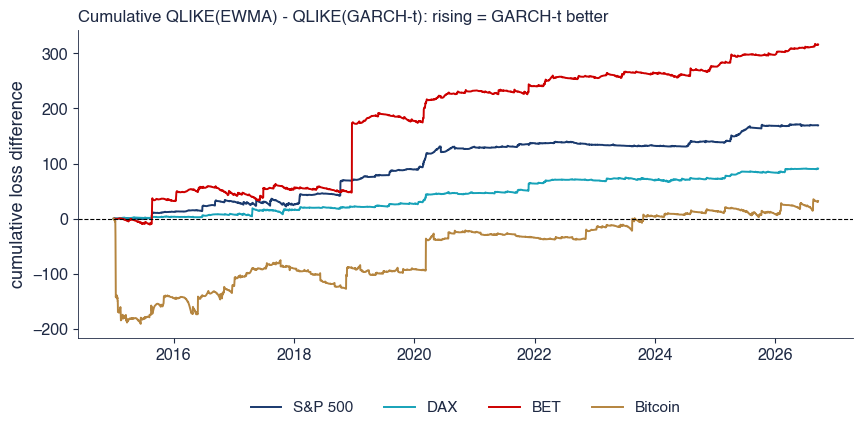

In [35]:
fig_forecast_eval(frames, save=False)

{'n': 505, 'exc_garch': 13, 'exc_ewma': 17}

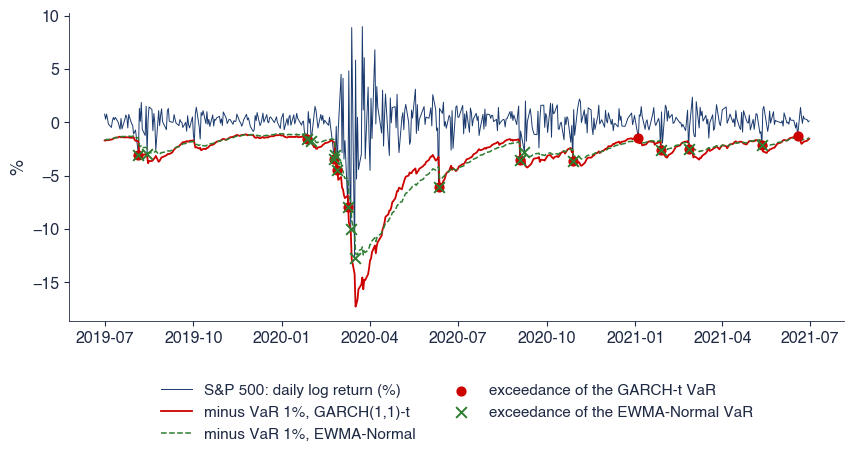

In [36]:
fig_var(frames, save=False)

## 10. AI for scientific discovery: is Bitcoin volatility becoming equity-like?

- Open question: has Bitcoin volatility moved closer to the volatility of the S&P 500 since 2021?
- Starter result: GJR-GARCH-t on 2015–2019 and 2021–2026 for both series.
- Check before trusting any answer, yours or an AI's: returns in %, the GJR persistence $\alpha + \beta + \gamma/2$, estimates on the boundary, different calendars, overlapping rolling windows.

In [37]:
for a, b in [('2015-01-01', '2019-12-31'), ('2021-01-01', '2026-09-18')]:
    for k in ('btc', 'sp500'):
        res = fit(returns(k).loc[a:b], o=1, dist='t')
        print(a[:4], b[:4], NAME[k], {n: round(v, 3) for n, v in res.params.items()}, 'persistence', round(persistence(res), 4))

2015 2019 Bitcoin {'mu': 0.173, 'omega': 0.101, 'alpha[1]': 0.144, 'gamma[1]': -0.059, 'beta[1]': 0.886, 'nu': 3.23} persistence 1.0
2015 2019 S&P 500 {'mu': 0.051, 'omega': 0.029, 'alpha[1]': 0.0, 'gamma[1]': 0.344, 'beta[1]': 0.795, 'nu': 5.324} persistence 0.9675
2021 2026 Bitcoin {'mu': 0.025, 'omega': 0.106, 'alpha[1]': 0.043, 'gamma[1]': 0.037, 'beta[1]': 0.938, 'nu': 3.28} persistence 0.9996
2021 2026 S&P 500 {'mu': 0.069, 'omega': 0.028, 'alpha[1]': 0.0, 'gamma[1]': 0.196, 'beta[1]': 0.872, 'nu': 7.737} persistence 0.9705
